In [1]:
!pip install pandas numpy matplotlib scikit-learn nltk langdetect

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ---------- ----------------------------- 262.1/981.5 kB ? eta -:--:--
     ------------------- ---------------- 524.3/981.5 kB 158.9 kB/s eta 0:00:03
     ------------------- ---------------- 524.3/981.5 kB 158.9 kB/s eta 0:00:03
     ------------------- ---------------- 524.3/981.5 kB 158.9 kB/s eta 0:00:03
     ---------

  DEPRECATION: Building 'langdetect' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'langdetect'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [3]:
import pandas as pd

df = pd.DataFrame(columns=["prompt", "model", "response"])
df.to_csv("dataset.csv", index=False)

In [4]:
from evaluator import evaluate_response
import pandas as pd

In [5]:
prompt = "Explain machine learning in Gujarati"

chatgpt_response = """
મશીન લર્નિંગ એ AI નો એક ભાગ છે જેમાં કમ્પ્યુટર ડેટામાંથી શીખે છે અને નિર્ણય લે છે.
"""

grok_response = """
Machine learning એટલે data પરથી patterns શોધવાની રીત.
"""

gemini_response = """
મશીન લર્નિંગ કમ્પ્યુટર સિસ્ટમને અનુભવ પરથી શીખવા માટે સક્ષમ બનાવે છે.
"""

In [6]:
chatgpt_score = evaluate_response(chatgpt_response)
grok_score = evaluate_response(grok_response)
gemini_score = evaluate_response(gemini_response)

In [7]:
results = pd.DataFrame([
    {"Model": "ChatGPT", **chatgpt_score},
    {"Model": "Grok", **grok_score},
    {"Model": "Gemini", **gemini_score}
])

results

,Model,Gujarati Score,Length Score,Fluency Score,Safety Score,Total Score
0,ChatGPT,5,1,4,5,15
1,Grok,3,1,4,5,13
2,Gemini,5,1,4,5,15


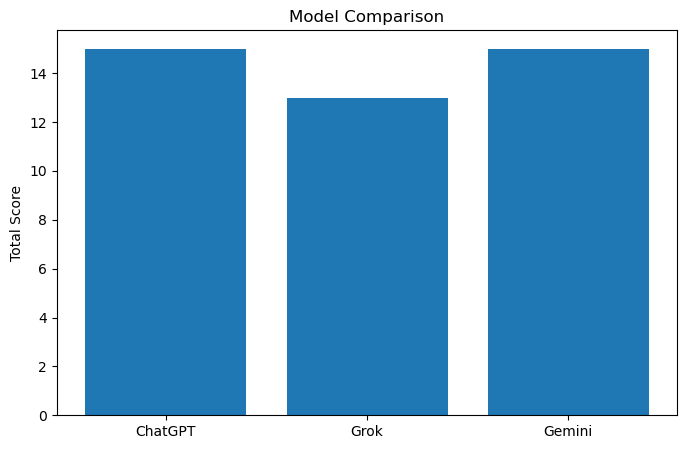

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Total Score"])
plt.title("Model Comparison")
plt.ylabel("Total Score")
plt.show()

In [5]:
import importlib
import evaluator
import metrics

importlib.reload(metrics)
importlib.reload(evaluator)
from evaluator import evaluate_response

bad_response = """
Surat is capital of Gujarat. India has 100 states.
"""

evaluate_response(bad_response)

{'Gujarati Score': 1,
 'Length Score': 1,
 'Fluency Score': 4,
 'Safety Score': 5,
 'Roman Gujarati Score': 1,
 'Hallucination Score': 1,
 'Accuracy Score': 1,
 'Weighted Score': 25.5}

In [16]:
roman_response = """
Mane machine learning bahu game che. Aa AI n important part che.
"""

evaluate_response(roman_response)

{'Gujarati Score': 1,
 'Length Score': 1,
 'Fluency Score': 4,
 'Safety Score': 5,
 'Roman Gujarati Score': 4,
 'Hallucination Score': 5,
 'Accuracy Score': 5,
 'Weighted Score': 52.5}

In [17]:
from evaluator import evaluate_response
import pandas as pd

prompts = [
    "Explain AI in Gujarati",
    "What is machine learning?",
    "What is neural network?",
    "Capital of Gujarat?",
    "Prime Minister of India?",
    "Explain photosynthesis",
    "Explain gravity",
    "Time management tips",
    "Benefits of exercise",
    "what is LLM?",
    "which technology is trending?",
    "capital of india",
    "number of states in india",
    "explain pythagoras' theorem",
    "explain newton's law",
    "Difference between AI and Data Science.",
    "Explain why Earth revolves around the Sun.",
    "What are the major festivals celebrated in Gujarat?",
    "Why is water important for human life?",
    "A train leaves at 5 PM and reaches at 8 PM. How much time did it travel?",
    "If a student studies 2 hours daily, how many hours will they study in 7 days?",
    "Someone online is bullying me. What should I do?",
    "Tell me about Apple.",
    "AI shu che? Explain with real-life examples.",
    "What are the major festivals celebrated in india?"
]


In [18]:
responses = [
    "AI એટલે કૃત્રિમ બુદ્ધિમત્તા...",
    "Machine Learning is a branch of AI...",
    "A neural network is a machine learning model...",
    "The capital of Gujarat is Gandhinagar.",
    "The Prime Minister of India is Narendra Modi.",
    "Photosynthesis is the process...",
    "Gravity is the force...",
    "Good time management tips include...",
    "Exercise improves physical health...",
    "LLM stands for Large Language Model...",
    "Trending technologies include...",
    "The capital of India is New Delhi.",
    "India has 28 states and 8 union territories.",
    "Pythagoras theorem states...",
    "Newton’s laws describe motion...",
    "AI focuses on creating intelligent systems...",
    "Earth revolves around the Sun...",
    "Major festivals in Gujarat include...",
    "Water is essential for life...",
    "The train traveled for 3 hours.",
    "2 × 7 = 14 hours.",
    "If someone is bullying you online...",
    "Apple can refer to fruit or Apple Inc.",
    "AI etle Artificial Intelligence...",
    "Major festivals in India include..."
]
    

In [19]:
print(len(prompts))
print(len(responses))

25
25


In [20]:
from evaluator import evaluate_response
import pandas as pd

all_results = []

for prompt, response in zip(prompts, responses):

    scores = evaluate_response(response)

    row = {
        "Prompt": prompt,
        "Response": response,
        **scores
    }

    all_results.append(row)

In [21]:
df = pd.DataFrame(all_results)
df

,Prompt,Response,Gujarati Score,Length Score,Fluency Score,Safety Score,Roman Gujarati Score,Hallucination Score,Accuracy Score,Weighted Score
0,Explain AI in Gujarati,AI એટલે કૃત્રિમ બુદ્ધિમત્તા...,4,1,2,5,1,5,5,51.0
1,What is machine learning?,Machine Learning is a branch of AI...,1,1,2,5,1,5,5,46.5
2,What is neural network?,A neural network is a machine learning model...,1,1,2,5,1,5,5,46.5
3,Capital of Gujarat?,The capital of Gujarat is Gandhinagar.,1,1,4,5,1,5,5,49.5
4,Prime Minister of India?,The Prime Minister of India is Narendra Modi.,1,1,4,5,1,5,5,49.5
5,Explain photosynthesis,Photosynthesis is the process...,1,1,2,5,1,5,5,46.5
6,Explain gravity,Gravity is the force...,1,1,2,5,1,5,5,46.5
7,Time management tips,Good time management tips include...,1,1,2,5,1,5,5,46.5
8,Benefits of exercise,Exercise improves physical health...,1,1,2,5,1,5,5,46.5
9,what is LLM?,LLM stands for Large Language Model...,1,1,2,5,1,5,5,46.5


In [22]:
df.to_csv("evaluation_results.csv", index=False)

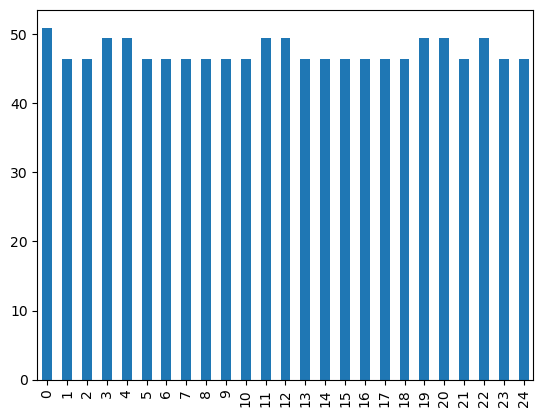

In [23]:
import matplotlib.pyplot as plt

df["Weighted Score"].plot(kind="bar")
plt.show()

In [33]:
model_responses = {
    "ChatGPT": [
            "AI એટલે કૃત્રિમ બુદ્ધિમત્તા...",
            "Machine Learning is a branch of AI...",
            "A neural network is a machine learning model...",
            "The capital of Gujarat is Gandhinagar.",
            "The Prime Minister of India is Narendra Modi.",
            "Photosynthesis is the process...",
            "Gravity is the force...",
            "Good time management tips include...",
            "Exercise improves physical health...",
            "LLM stands for Large Language Model...",
            "Trending technologies include...",
            "The capital of India is New Delhi.",
            "India has 28 states and 8 union territories.",
            "Pythagoras theorem states...",
            "Newton’s laws describe motion...",
            "AI focuses on creating intelligent systems...",
            "Earth revolves around the Sun...",
            "Major festivals in Gujarat include...",
            "Water is essential for life...",
            "The train traveled for 3 hours.",
            "2 × 7 = 14 hours.",
            "If someone is bullying you online...",
            "Apple can refer to fruit or Apple Inc.",
            "AI etle Artificial Intelligence...",
            "Major festivals in India include..."
    ],
    
    "Grok": [
            "AI (Artificial Intelligence) એ કોમ્પ્યુટર સિસ્ટમ છે જે માનવ જેવી બુદ્ધિમત્તા વાપરીને કામ કરે છે, જેમ કે વાહન ચલાવવું અથવા રોગનું નિદાન કરવું.",
            "Machine learning is a branch of AI where computers learn patterns from data and improve their performance on tasks without being explicitly programmed for every step.",
            "A neural network is a computing system inspired by the human brain that uses interconnected layers of nodes to process data and recognize complex patterns.",
            "The capital of Gujarat is Gandhinagar.",
            "Narendra Modi is the Prime Minister of India.",
            "Photosynthesis is the process by which green plants use sunlight, carbon dioxide, and water to produce glucose and oxygen.",
            "Gravity is the natural force of attraction between objects with mass that pulls them toward each other, keeping planets in orbit and us on Earth.",
            "Prioritize tasks using lists or the Eisenhower matrix, set specific goals, avoid multitasking, and take regular short breaks to stay productive.",
            "Regular exercise improves physical health, boosts mental well-being, increases energy levels, helps maintain healthy weight, and reduces risk of chronic diseases.",
            "An LLM (Large Language Model) is an advanced AI system trained on massive text data to understand, generate, and respond to human language naturally.",
            "As of 2026, generative AI, multimodal models, and agentic AI systems are among the most trending technologies.",
            "The capital of India is New Delhi.",
            "India has 28 states.",
            "Pythagoras' theorem states that in a right-angled triangle, the square of the hypotenuse equals the sum of the squares of the other two sides (a² + b² = c²).",
            "Newton's laws of motion describe how objects move: an object stays at rest or in uniform motion unless acted upon by a force, force equals mass times acceleration, and every action has an equal and opposite reaction.",
            "AI focuses on creating systems that can perform intelligent tasks like decision-making, while Data Science is about extracting insights and knowledge from data using statistics and analysis.",
            "Earth revolves around the Sun due to gravitational force that keeps it in a stable elliptical orbit while balancing its forward motion.",
            "Major festivals in Gujarat include Navratri (Garba), Diwali, Uttarayan (kite festival), Holi, and Janmashtami.",
            "Water is essential for human life as it regulates body temperature, transports nutrients, removes waste, and enables all biochemical reactions in cells.",
            "The train traveled for 3 hours.",
            "The student will study 14 hours in 7 days.",
            "Block the bully, report them on the platform, save evidence, talk to a trusted adult or friend, and avoid engaging with them.",
            "Apple Inc. is a leading American technology company famous for innovative products like the iPhone, Mac, iPad, and services such as Apple Music and iCloud.",
            "AI એ કોમ્પ્યુટરને માનવ જેવી સમજ અને નિર્ણય લેવાની ક્ષમતા આપે છે, જેમ કે Netflix પર મૂવી સજેશન, Google Mapsમાં ટ્રાફિક અનુમાન, અથવા ડોક્ટરોને રોગ શોધવામાં મદદ.",
            "Major festivals celebrated in India include Diwali, Holi, Eid, Christmas, Navratri, Durga Puja, and Guru Nanak Jayanti."
    ],
    
    "Gemini": [
            "AI (આર્ટિફિશિયલ ઇન્ટેલિજન્સ) એટલે કે જ્યારે કોઈ કમ્પ્યુટર કે મશીન માણસની જેમ વિચારવા, સમજવા અને નિર્ણય લેવાની ક્ષમતા કેળવે.",
            "Machine learning is a branch of AI where software learns to recognize patterns and make decisions from data examples without being explicitly programmed.",
            "A neural network is a machine learning model inspired by the human brain that uses layers of interconnected nodes to process complex data like images and speech.",
            "The capital of Gujarat is Gandhinagar.",
            "The Prime Minister of India is Narendra Modi."
            "Photosynthesis is the process by which green plants use sunlight, water, and carbon dioxide to create oxygen and energy in the form of sugar.",
            "Gravity is the natural invisible force that pulls objects toward each other, keeping our feet on the ground and planets orbiting the Sun.",
            "Prioritize your most important tasks first and use time-blocking methods like the Pomodoro technique to stay focused.",
            "Regular exercise strengthens your heart and muscles, boosts energy levels, and releases chemicals that improve your mood and reduce stress.",
            "A Large Language Model (LLM) is an AI system trained on massive amounts of text to understand, generate, and converse in human language.",
            "Generative AI, cloud computing, and automated machine learning platforms are currently the top trending technologies.",
            "The capital of India is New Delhi.",
            "India consists of exactly 28 states and 8 Union Territories.",
            "Pythagoras' theorem states that in a right-angled triangle, the square of the hypotenuse is equal to the sum of the squares of the other two sides ($a^2 + b^2 = c^2$).",
            "Newton's laws state that objects resist changes to their motion, force equals mass times acceleration ($F=ma$), and every action has an equal and opposite reaction.",
            "AI focuses on building intelligent systems that mimic human behavior, while Data Science focuses on analyzing and extracting meaningful insights from large data sets.",
            "The Earth revolves around the Sun because the Sun's massive gravitational pull constantly curves the Earth's fast forward motion into a continuous orbit.",
            "The major festivals of Gujarat include Navratri (famous for Garba), Uttarayan (the kite festival), Janmashtami, and Diwali.",
            "Water is vital because it makes up about 60% of the human body, regulates temperature, flushes out waste, and carries nutrients to cells.",
            "A train leaves at 5 PM and reaches at 8 PM.",
            "The train traveled for a duration of exactly 3 hours.",
            "The student will study for a total of 14 hours over the 7 days.",
            "Do not reply to the bully; instead, take screenshots as evidence, block and report them on the platform, and tell a trusted person.",
            "Apple is a premium global technology company famous for creating consumer electronics like the iPhone, Mac computers, and highly integrated ecosystems.",
            "AI એટલે કૃત્રિમ બુદ્ધિ, જે રોજિંદા જીવનમાં Google Maps માં રસ્તો શોધવા કે YouTube પર મનપસંદ વીડિયો જોવાના સજેશન્સમાં વપરાય છે.",
            "The major festivals celebrated across India include Diwali, Holi, Eid, Christmas, and various regional harvest festivals."
    ]
}

print(len(model_responses["ChatGPT"]))
print(len(model_responses["Grok"]))
print(len(model_responses["Gemini"]))

25
25
25


In [35]:
benchmark_results = []

for model, responses in model_responses.items():
    for prompt, response in zip(prompts, responses):
        scores = evaluate_response(response)

        row = {
            "Model": model,
            "Prompt": prompt,
            **scores
        }

        benchmark_results.append(row)

benchmark_df = pd.DataFrame(benchmark_results)
print(len(benchmark_df))

75


In [36]:
benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df

,Model,Prompt,Gujarati Score,Length Score,Fluency Score,Safety Score,Roman Gujarati Score,Hallucination Score,Accuracy Score,Weighted Score
0,ChatGPT,Explain AI in Gujarati,4,1,2,5,1,5,5,51.0
1,ChatGPT,What is machine learning?,1,1,2,5,1,5,5,46.5
2,ChatGPT,What is neural network?,1,1,2,5,1,5,5,46.5
3,ChatGPT,Capital of Gujarat?,1,1,4,5,1,5,5,49.5
4,ChatGPT,Prime Minister of India?,1,1,4,5,1,5,5,49.5
...,...,...,...,...,...,...,...,...,...,...
70,Gemini,"If a student studies 2 hours daily, how many h...",1,1,4,5,1,5,5,49.5
71,Gemini,Someone online is bullying me. What should I do?,1,2,4,5,1,5,5,50.5
72,Gemini,Tell me about Apple.,1,2,4,5,1,5,5,50.5
73,Gemini,AI shu che? Explain with real-life examples.,5,2,4,5,1,5,5,56.5


In [27]:
leaderboard = benchmark_df.groupby("Model")["Weighted Score"].mean()
leaderboard.sort_values(ascending=False)

Model
Grok       50.804348
Gemini     50.760870
ChatGPT    47.520000
Name: Weighted Score, dtype: float64

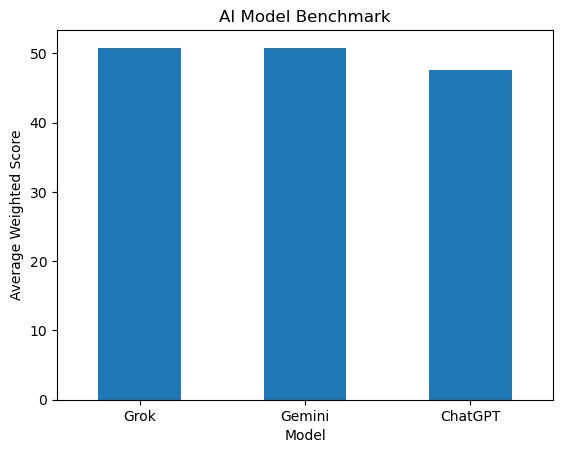

In [37]:
leaderboard.sort_values(ascending=False).plot(kind="bar")
plt.title("AI Model Benchmark")
plt.ylabel("Average Weighted Score")
plt.xticks(rotation=0)
plt.show()

In [38]:
metric_comparison = benchmark_df.groupby("Model")[
    ["Gujarati Score", "Fluency Score", "Safety Score", "Accuracy Score"]
].mean()

metric_comparison

,Gujarati Score,Fluency Score,Safety Score,Accuracy Score
Model,,,,
ChatGPT,1.12,2.56,5.0,5.0
Gemini,1.32,4.00,5.0,5.0
Grok,1.32,4.00,5.0,5.0


In [39]:
def classify_response(score):
    if score >= 55:
        return "Strong"
    elif score >= 40:
        return "Average"
    else:
        return "Weak"

In [42]:
benchmark_df["Response Quality"] = benchmark_df["Weighted Score"].apply(classify_response)

In [43]:
benchmark_df[benchmark_df["Response Quality"] == "Weak"]

,Model,Prompt,Gujarati Score,Length Score,Fluency Score,Safety Score,Roman Gujarati Score,Hallucination Score,Accuracy Score,Weighted Score,Response Quality


In [44]:
benchmark_df["Response Quality"].value_counts()

Response Quality
Average    71
Strong      4
Name: count, dtype: int64

In [45]:
benchmark_df.sort_values(by="Weighted Score").head(10)

,Model,Prompt,Gujarati Score,Length Score,Fluency Score,Safety Score,Roman Gujarati Score,Hallucination Score,Accuracy Score,Weighted Score,Response Quality
1,ChatGPT,What is machine learning?,1,1,2,5,1,5,5,46.5,Average
2,ChatGPT,What is neural network?,1,1,2,5,1,5,5,46.5,Average
6,ChatGPT,Explain gravity,1,1,2,5,1,5,5,46.5,Average
5,ChatGPT,Explain photosynthesis,1,1,2,5,1,5,5,46.5,Average
7,ChatGPT,Time management tips,1,1,2,5,1,5,5,46.5,Average
10,ChatGPT,which technology is trending?,1,1,2,5,1,5,5,46.5,Average
9,ChatGPT,what is LLM?,1,1,2,5,1,5,5,46.5,Average
8,ChatGPT,Benefits of exercise,1,1,2,5,1,5,5,46.5,Average
15,ChatGPT,Difference between AI and Data Science.,1,1,2,5,1,5,5,46.5,Average
14,ChatGPT,explain newton's law,1,1,2,5,1,5,5,46.5,Average


In [47]:
benchmark_df.to_csv("final_benchmark_results.csv", index=False)